In [4]:
import numpy as np
import pandas as pd
from wordcloud import WordCloud,STOPWORDS,ImageColorGenerator
from PIL import Image
stopwords=set(STOPWORDS)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
pd.options.display.max_colwidth=1000
nltk.download('stopwords')
nltk.download('punkt')



[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [5]:
df=pd.read_csv('/kaggle/input/testin/test(in).csv')
df.head()

,Subject,body,date,from
0,EnronOptions Update!,"EnronOptions Announcement\n\n\nWe have updated the EnronOptions =01) Your Stock Option Program web site! =\nThe=20\nweb site now contains specific details of the EnronOptions Program includin=\ng=20\nthe December 29, 2000 grant price and additional information on employee=20\neligibility.\n\nAccess EnronOptions =01) Your Stock Option Program web site by clicking on=\n=20\nhttp://hrweb.enron.com or by typing the address into your web browser.\n\nWe hope you find the revised site helpful in addressing your questions abou=\nt=20\nthe EnronOptions Program. If you have any additional questions, please=20\ncontact your H.R. Representative.\n\nStay tuned for more information throughout March and April 2001.",5/10/2010,sally.beck@enron.com
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to work for the revenue model for mid & \nback office services meeting. How about this coming Monday, Feb 26 from 1:00 \n- 2:30 pm? I have penciled in that time for Sally, Mary Solmonson & James \nScribner. Please let me know if that will work for you.\n\nThanks,\nPatti x39106",7/29/2010,eric.bass@enron.com
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 AM (GMT-06:00) Central Time (US & Canada).\nWhere: @ 10:00am CST (225) 931-8111\n\n*~*~*~*~*~*~*~*~*~*\n\n",7/25/2011,sally.beck@enron.com
3,RE: My new work email,we were thinking papasitos (we can meet somewhere closer to you this time) \nagain at around 8\n\n\n\n\nJason Bass <JBass@stdauto.com> on 02/21/2001 11:22:45 AM\n,3/25/2010,johnny.palmer@enron.com
4,Bet,"Since you never gave me the $20 for the last time we bet on CU/Texas, I figured I would give you the chance to go double or nothing on the second round. I think the line is Texas -9. Let me know.",5/21/2011,lydia.delgado@enron.com


# Understanding the dataset

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Subject  2191 non-null   object
 1   body     2191 non-null   object
 2   date     2191 non-null   object
 3   from     2191 non-null   object
dtypes: object(4)
memory usage: 68.6+ KB


In [7]:
df.describe()

,Subject,body,date,from
count,2191,2191,2191,2191
unique,1251,1539,690,10
top,(No Subject),\n\n,7/1/2011,lydia.delgado@enron.com
freq,141,21,9,284


In [8]:
print(df['from'].unique())
df['from'].nunique()# finding the no of employees 

['sally.beck@enron.com' 'eric.bass@enron.com' 'johnny.palmer@enron.com'
 'lydia.delgado@enron.com' 'kayne.coulter@enron.com'
 'patti.thompson@enron.com' 'rhonda.denton@enron.com'
 'don.baughman@enron.com' 'john.arnold@enron.com'
 'bobette.riner@ipgdirect.com']


10

In [9]:
df.rename(columns={'from':'Employee'}, inplace=True)#renaming coloumn for better undertanding 

In [10]:
df.duplicated().sum()


0

# Cleaning Data for Sentimental Analysis 



In [11]:
def clean_msg(msg):
    msg = str(msg).lower()

    # Remove URLs
    msg = re.sub(r'http\S+|www.\S+', '', msg)

    # Remove mentions and hashtags
    msg = re.sub(r'@\w+|#\w+', '', msg)

    # Remove emojis
    msg = re.sub(r'[^\x00-\x7F]+', '', msg)

    # Remove special characters & numbers
    msg = re.sub(r'[^a-zA-Z\s]', '', msg)
    
    #Remove time AM and PM
    msg = re.sub(r'\b(AM|PM|am|pm)\b', '', msg)


    # Remove extra spaces
    msg = re.sub(r'\s+', ' ', msg).strip()

    return msg


In [12]:
df["clean_body"] = df["body"].apply(clean_msg) # Cleaning msg in body 
df

,Subject,body,date,Employee,clean_body
0,EnronOptions Update!,"EnronOptions Announcement\n\n\nWe have updated the EnronOptions =01) Your Stock Option Program web site! =\nThe=20\nweb site now contains specific details of the EnronOptions Program includin=\ng=20\nthe December 29, 2000 grant price and additional information on employee=20\neligibility.\n\nAccess EnronOptions =01) Your Stock Option Program web site by clicking on=\n=20\nhttp://hrweb.enron.com or by typing the address into your web browser.\n\nWe hope you find the revised site helpful in addressing your questions abou=\nt=20\nthe EnronOptions Program. If you have any additional questions, please=20\ncontact your H.R. Representative.\n\nStay tuned for more information throughout March and April 2001.",5/10/2010,sally.beck@enron.com,enronoptions announcement we have updated the enronoptions your stock option program web site the web site now contains specific details of the enronoptions program includin g the december grant price and additional information on employee eligibility access enronoptions your stock option program web site by clicking on or by typing the address into your web browser we hope you find the revised site helpful in addressing your questions abou t the enronoptions program if you have any additional questions please contact your hr representative stay tuned for more information throughout march and april
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to work for the revenue model for mid & \nback office services meeting. How about this coming Monday, Feb 26 from 1:00 \n- 2:30 pm? I have penciled in that time for Sally, Mary Solmonson & James \nScribner. Please let me know if that will work for you.\n\nThanks,\nPatti x39106",7/29/2010,eric.bass@enron.com,marc unfortunately today is not going to work for the revenue model for mid back office services meeting how about this coming monday feb from i have penciled in that time for sally mary solmonson james scribner please let me know if that will work for you thanks patti x
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 AM (GMT-06:00) Central Time (US & Canada).\nWhere: @ 10:00am CST (225) 931-8111\n\n*~*~*~*~*~*~*~*~*~*\n\n",7/25/2011,sally.beck@enron.com,when wednesday june gmt central time us canada where cst
3,RE: My new work email,we were thinking papasitos (we can meet somewhere closer to you this time) \nagain at around 8\n\n\n\n\nJason Bass <JBass@stdauto.com> on 02/21/2001 11:22:45 AM\n,3/25/2010,johnny.palmer@enron.com,we were thinking papasitos we can meet somewhere closer to you this time again at around jason bass jbasscom on
4,Bet,"Since you never gave me the $20 for the last time we bet on CU/Texas, I figured I would give you the chance to go double or nothing on the second round. I think the line is Texas -9. Let me know.",5/21/2011,lydia.delgado@enron.com,since you never gave me the for the last time we bet on cutexas i figured i would give you the chance to go double or nothing on the second round i think the line is texas let me know
...,...,...,...,...,...
2186,Re: Resume,Thanks for the resume. She has had some good experience. Do you know much \nabout her performance here at Enron? Can I call and talk with her directly? \nI would certainly keep the conversation confidential at this point. --Sally \n\n\n\n\nVince J Kaminski\n11/21/2000 08:14 AM\n,6/17/2011,johnny.palmer@enron.com,thanks for the resume she has had some good experience do you know much about her performance here at enron can i call and talk with her directly i would certainly keep the conversation confidential at this point sally vince j kaminski
2187,"Final Schedule - Wednesday, May 2, 2001 - Jesus O. Guerra","Attached please find the following documents:\n\n\n \n\n\nThanks,\nLydia\n\nx3-9338",1/20/2011,johnny.palmer@enron.com,attached please find the following documents thanks lydia x
2188,(No Subject),"Good to finally hear from. Judging from your e-mail

In [13]:
def calcpolarity(msg):
    return TextBlob(msg).sentiment.polarity


def calcsubjectivity(msg):
    return TextBlob(msg).sentiment.subjectivity

def segmentation(msg):
    if msg > 0:
        return 'positive'
    elif msg == 0 :
        return 'neutral'
    else:
        return 'negative' # function to give us sentiment polarity scores from -1 to 1 (-1 being negative messages +1 being positive )

In [14]:
df["Polarity"] = df["clean_body"].apply(calcpolarity) # Cleaning msg in body 
df["Subjectivity"] = df["clean_body"].apply(calcsubjectivity) # C
df["Segmentation"] = df["Polarity"].apply(segmentation) # C
#adding the coloums to our dataframe


In [15]:
df.head()

,Subject,body,date,Employee,clean_body,Polarity,Subjectivity,Segmentation
0,EnronOptions Update!,"EnronOptions Announcement\n\n\nWe have updated the EnronOptions =01) Your Stock Option Program web site! =\nThe=20\nweb site now contains specific details of the EnronOptions Program includin=\ng=20\nthe December 29, 2000 grant price and additional information on employee=20\neligibility.\n\nAccess EnronOptions =01) Your Stock Option Program web site by clicking on=\n=20\nhttp://hrweb.enron.com or by typing the address into your web browser.\n\nWe hope you find the revised site helpful in addressing your questions abou=\nt=20\nthe EnronOptions Program. If you have any additional questions, please=20\ncontact your H.R. Representative.\n\nStay tuned for more information throughout March and April 2001.",5/10/2010,sally.beck@enron.com,enronoptions announcement we have updated the enronoptions your stock option program web site the web site now contains specific details of the enronoptions program includin g the december grant price and additional information on employee eligibility access enronoptions your stock option program web site by clicking on or by typing the address into your web browser we hope you find the revised site helpful in addressing your questions abou t the enronoptions program if you have any additional questions please contact your hr representative stay tuned for more information throughout march and april,0.250,0.312500,positive
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to work for the revenue model for mid & \nback office services meeting. How about this coming Monday, Feb 26 from 1:00 \n- 2:30 pm? I have penciled in that time for Sally, Mary Solmonson & James \nScribner. Please let me know if that will work for you.\n\nThanks,\nPatti x39106",7/29/2010,eric.bass@enron.com,marc unfortunately today is not going to work for the revenue model for mid back office services meeting how about this coming monday feb from i have penciled in that time for sally mary solmonson james scribner please let me know if that will work for you thanks patti x,-0.075,0.300000,negative
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 AM (GMT-06:00) Central Time (US & Canada).\nWhere: @ 10:00am CST (225) 931-8111\n\n*~*~*~*~*~*~*~*~*~*\n\n",7/25/2011,sally.beck@enron.com,when wednesday june gmt central time us canada where cst,0.000,0.250000,neutral
3,RE: My new work email,we were thinking papasitos (we can meet somewhere closer to you this time) \nagain at around 8\n\n\n\n\nJason Bass <JBass@stdauto.com> on 02/21/2001 11:22:45 AM\n,3/25/2010,johnny.palmer@enron.com,we were thinking papasitos we can meet somewhere closer to you this time again at around jason bass jbasscom on,-0.150,0.500000,negative
4,Bet,"Since you never gave me the $20 for the last time we bet on CU/Texas, I figured I would give you the chance to go double or nothing on the second round. I think the line is Texas -9. Let me know.",5/21/2011,lydia.delgado@enron.com,since you never gave me the for the last time we bet on cutexas i figured i would give you the chance to go double or nothing on the second round i think the line is texas let me know,-0.050,0.116667,negative


In [16]:
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')


In [17]:
monthly_avg = df.pivot_table(
    index='Employee',
    columns='year_month',
    values='Polarity',
    aggfunc='mean'
)
monthly_avg.head(10)# using pivot table to give us the aggregated sentiment scores we require for better visualization and further analysis

year_month,2010-01,2010-02,2010-03,2010-04,2010-05,2010-06,2010-07,2010-08,2010-09,2010-10,...,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,2011-12
Employee,,,,,,,,,,,,,,,,,,,,,
bobette.riner@ipgdirect.com,0.168182,0.097440,0.111059,0.123347,0.096354,0.016818,0.137988,-0.044321,0.090324,0.197619,...,0.143908,0.168568,0.133333,0.184284,0.048350,0.145318,0.121477,0.000000,0.105830,0.018929
don.baughman@enron.com,0.108565,0.097659,0.159506,0.154664,0.124705,0.133842,0.069444,0.358333,0.050000,0.068182,...,0.074866,0.157667,0.095592,0.037500,0.030541,0.097191,0.090351,0.213705,0.066304,0.210290
eric.bass@enron.com,0.155492,0.239378,0.086875,0.050000,0.195275,0.000000,0.098543,0.085833,0.063175,0.189380,...,0.046677,0.141198,0.111487,0.087559,0.148039,0.157657,0.126888,0.180359,0.600000,0.068681
john.arnold@enron.com,0.104906,0.134113,0.068973,0.193687,0.018109,0.118857,0.114827,0.061281,0.065407,0.093628,...,0.164931,0.241667,0.136537,0.234134,0.138037,0.220599,0.200000,0.087977,0.159629,0.133333
johnny.palmer@enron.com,0.027904,0.108275,0.070482,0.099148,0.100000,0.121837,-0.029853,0.142262,0.089409,0.117835,...,0.000000,0.210300,0.145475,0.214696,0.214444,0.108256,0.069343,0.062500,0.100907,0.183333
kayne.coulter@enron.com,0.039196,0.084861,0.098438,0.030479,0.150000,-0.106250,0.122500,0.158820,0.112500,0.045455,...,0.144318,0.023092,0.400000,0.000000,0.000000,0.200000,0.268719,0.187331,0.158200,0.198187
lydia.delgado@enron.com,0.158375,0.237500,0.131108,0.134280,0.083833,0.109007,0.102616,0.044363,0.087000,0.087973,...,0.313158,0.085189,0.112611,0.163611,0.100000,0.127158,0.113986,0.118502,0.039322,0.107207
patti.thompson@enron.com,0.194261,0.213851,0.061198,0.095410,0.099820,0.139692,0.100000,0.216667,0.213478,0.052546,...,0.054228,0.150464,-0.127778,0.147222,0.122821,0.091725,0.158371,0.189983,0.156164,0.156071
rhonda.denton@enron.com,0.000000,0.241667,0.000000,0.065113,0.163757,0.082407,0.133333,0.024760,0.290417,0.107500,...,0.105053,0.079167,0.192708,0.078464,0.185937,0.600000,0.163651,0.000000,0.090000,0.112285


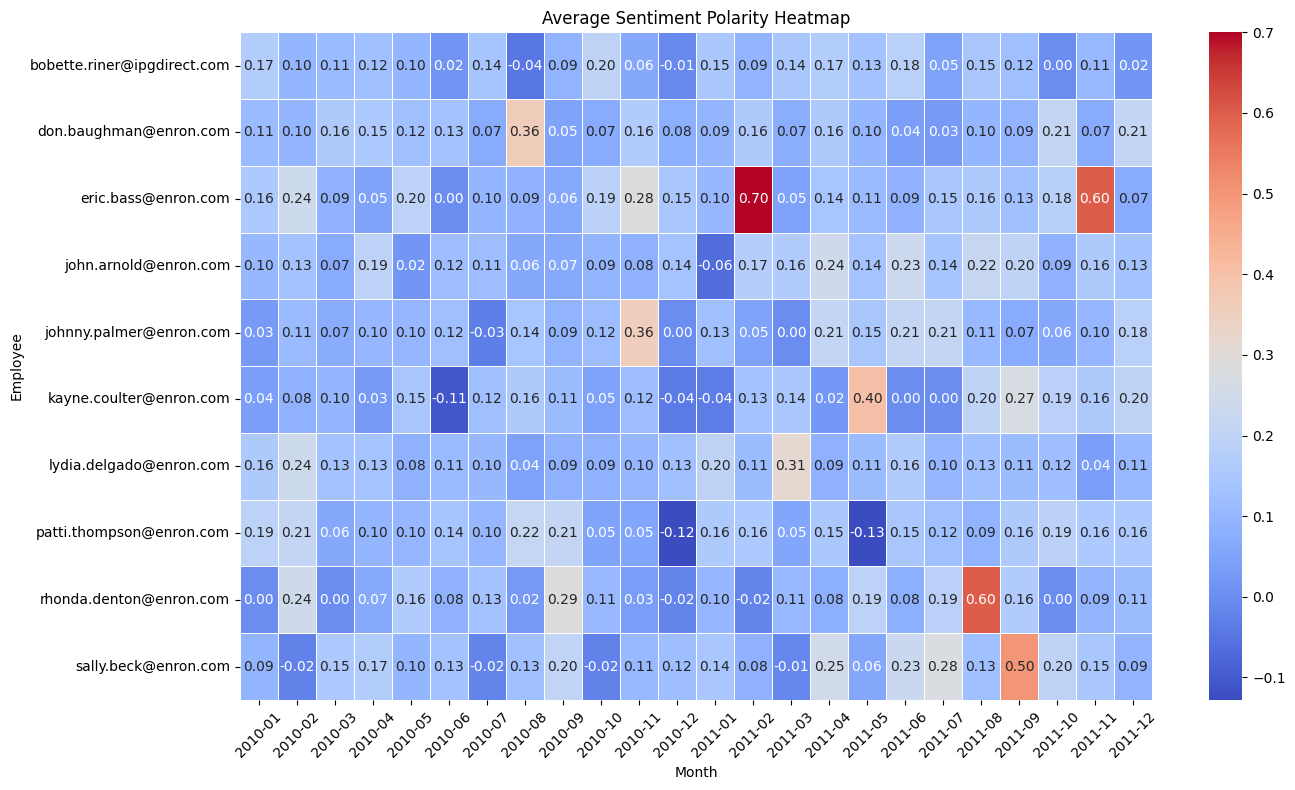

In [18]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    monthly_avg,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5
)

plt.title("Average Sentiment Polarity Heatmap")
plt.xlabel("Month")
plt.ylabel("Employee")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### from the heatmap we can observe the trend of employees sentiments over the months much more easily the darker the blue more negative the avg sentiment of msg of the employee and as it gets more red more positive the messages 


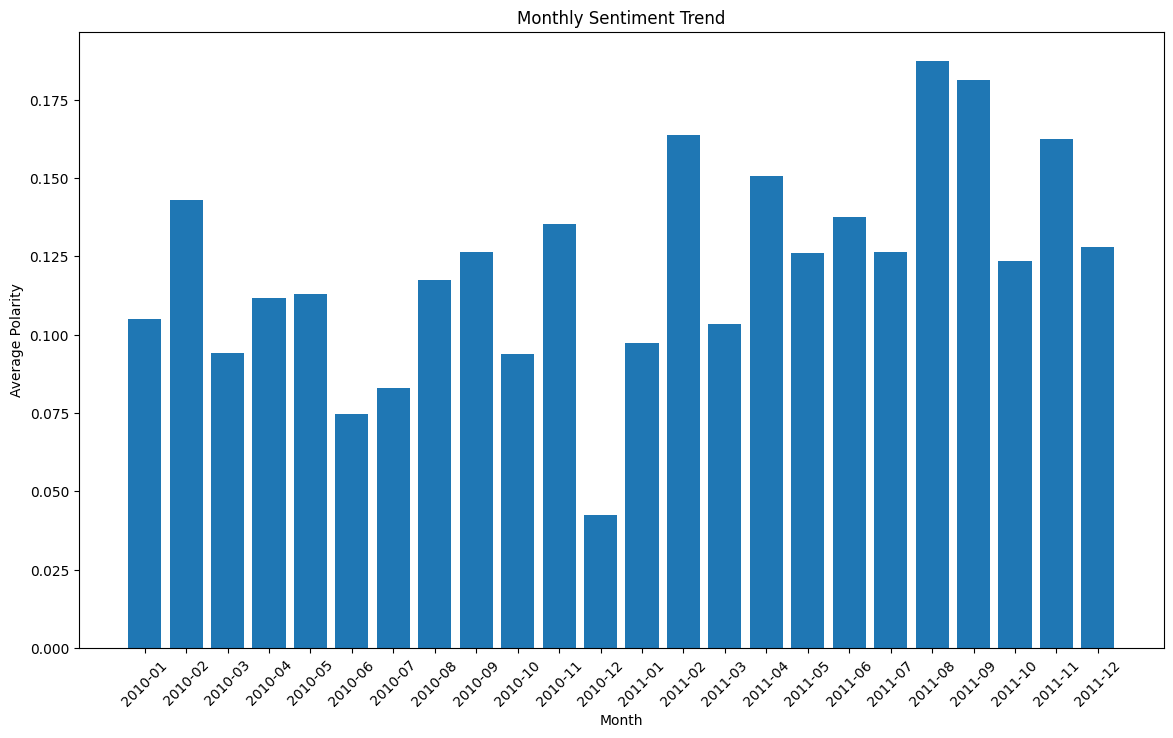

In [19]:
monthly_avg_of_means = monthly_avg.mean(axis=0)

monthly_avg_of_means

plt.figure(figsize=(14,8))
plt.bar(monthly_avg_of_means.index.astype(str), monthly_avg_of_means.values)
plt.xlabel('Month')
plt.ylabel('Average Polarity')
plt.title('Monthly Sentiment Trend')
plt.xticks(rotation=45)
plt.show()
#

### This bar graph shows the avg sentiment of all employees over the months 

In [20]:
rows = []

for col in monthly_avg.columns:
    col_sorted = monthly_avg[col].sort_values(ascending=False)

    for emp, val in col_sorted.head(3).items():
        rows.append([col, emp, val, "Top 3 Positive"])

    for emp, val in col_sorted.tail(3).items():
        rows.append([col, emp, val, "Top 3 Negative "])

final_table = pd.DataFrame(rows, columns=["year_month", "Employee", "Polarity", "Rank"])


In [21]:
final_table.head()
# one concatenated table which holds all top 3 positive and negative ranked employee 

,year_month,Employee,Polarity,Rank
0,2010-01,patti.thompson@enron.com,0.194261,Top 3 Positive
1,2010-01,bobette.riner@ipgdirect.com,0.168182,Top 3 Positive
2,2010-01,lydia.delgado@enron.com,0.158375,Top 3 Positive
3,2010-01,kayne.coulter@enron.com,0.039196,Top 3 Negative
4,2010-01,johnny.palmer@enron.com,0.027904,Top 3 Negative


In [22]:
top_bottom = {}

for col in monthly_avg.columns:
    col_sorted = monthly_avg[col].sort_values(ascending=False)

    top3 = col_sorted.head(3)
    bottom3 = col_sorted.tail(3)[::-1]

    top_bottom[col] = {
        "Top 3": top3,
        "Bottom 3": bottom3
    }


### Ranking of Employees categorised by months


In [23]:
for month, data in top_bottom.items():
    print(f"\n=== {month} ===")
    print("Top 3 Positive Employees:")
    print(data["Top 3"])
    print("\Top 3 Negative Employees:")
    print(data["Bottom 3"])



=== 2010-01 ===
Top 3 Positive Employees:
Employee
patti.thompson@enron.com       0.194261
bobette.riner@ipgdirect.com    0.168182
lydia.delgado@enron.com        0.158375
Name: 2010-01, dtype: float64
\Top 3 Negative Employees:
Employee
rhonda.denton@enron.com    0.000000
johnny.palmer@enron.com    0.027904
kayne.coulter@enron.com    0.039196
Name: 2010-01, dtype: float64

=== 2010-02 ===
Top 3 Positive Employees:
Employee
rhonda.denton@enron.com    0.241667
eric.bass@enron.com        0.239378
lydia.delgado@enron.com    0.237500
Name: 2010-02, dtype: float64
\Top 3 Negative Employees:
Employee
sally.beck@enron.com          -0.024306
kayne.coulter@enron.com        0.084861
bobette.riner@ipgdirect.com    0.097440
Name: 2010-02, dtype: float64

=== 2010-03 ===
Top 3 Positive Employees:
Employee
don.baughman@enron.com     0.159506
sally.beck@enron.com       0.153579
lydia.delgado@enron.com    0.131108
Name: 2010-03, dtype: float64
\Top 3 Negative Employees:
Employee
rhonda.denton@enron.co

## flight risk detection

In [24]:
from datetime import timedelta

def detect_flight_risk(df, min_neg=4, window_days=30):
    df = df.copy()
    df['Segmentation'] = df['Segmentation'].str.lower()
    
    # keep only -ve messages 
    neg_df = df[df['Segmentation'] == 'negative'].copy()
    neg_df = neg_df.sort_values(['Employee', 'date']).reset_index(drop=True)
    
    flight_risk = {}

    for emp, group in neg_df.groupby('Employee'):
        group = group.reset_index(drop=True)

        if len(group) < min_neg:
            continue

        for i in range(len(group) - min_neg + 1):
            start_date = group.loc[i, 'date']
            end_date = start_date + timedelta(days=window_days) # creating the rolling 30 day window instead of a fixed 30 day from each month

            # Count negatives in 30-day window
            count_in_window = group[
                (group['date'] >= start_date) & 
                (group['date'] <= end_date)
            ]

            if len(count_in_window) >= min_neg:
                flight_risk[emp] = {
                    "window_start": start_date,
                    "window_end": end_date,
                    "negative_count": len(count_in_window),   # finaL condition block to count the no of negative messages over the 30 day rolling window 
                    "first_negative": count_in_window.iloc[0]['date'],
                    "last_negative": count_in_window.iloc[-1]['date']
                }
                break  

    return flight_risk


In [25]:
flight_risk_employees = detect_flight_risk(df)

flight_risk_df = (
    pd.DataFrame.from_dict(flight_risk_employees, orient='index')
      .reset_index()
      .rename(columns={'index': 'Employee'})
)

flight_risk_df


,Employee,window_start,window_end,negative_count,first_negative,last_negative
0,bobette.riner@ipgdirect.com,2010-11-02,2010-12-02,5,2010-11-02,2010-11-19
1,don.baughman@enron.com,2010-02-13,2010-03-15,4,2010-02-13,2010-03-07
2,eric.bass@enron.com,2010-03-19,2010-04-18,4,2010-03-19,2010-04-15
3,john.arnold@enron.com,2010-05-25,2010-06-24,5,2010-05-25,2010-06-21
4,johnny.palmer@enron.com,2010-02-14,2010-03-16,5,2010-02-14,2010-03-10
5,kayne.coulter@enron.com,2011-11-26,2011-12-26,4,2011-11-26,2011-12-26
6,lydia.delgado@enron.com,2010-10-28,2010-11-27,4,2010-10-28,2010-11-25
7,patti.thompson@enron.com,2010-04-05,2010-05-05,4,2010-04-05,2010-05-02
8,rhonda.denton@enron.com,2010-08-10,2010-09-09,4,2010-08-10,2010-08-28
9,sally.beck@enron.com,2010-06-16,2010-07-16,5,2010-06-16,2010-07-07


### All 10 employees have been found to be in flight risk over the given data frame 


# predictive modelling 

In [26]:
# Basic text-based numeric features
df['message_length'] = df['body'].str.len()
df['word_count'] = df['body'].str.split().str.len()

# Group-level monthly features
monthly_features = (
    df.groupby(['Employee', 'date'])
      .agg({
          'Polarity': 'mean',          # avg sentiment
          'message_length': 'mean',    # avg msg length
          'word_count': 'mean',        # avg word count
          'body': 'count'              # message frequency
      })
      .rename(columns={
          'Polarity': 'avg_polarity',
          'message_length': 'avg_msg_length',
          'word_count': 'avg_word_count',
          'body': 'msg_frequency'
      })
      .reset_index()
)

monthly_features.head()


,Employee,date,avg_polarity,avg_msg_length,avg_word_count,msg_frequency
0,bobette.riner@ipgdirect.com,2010-01-23,0.136364,67.000000,11.000000,1
1,bobette.riner@ipgdirect.com,2010-01-25,0.200000,163.000000,26.000000,1
2,bobette.riner@ipgdirect.com,2010-02-03,0.432273,890.000000,135.000000,1
3,bobette.riner@ipgdirect.com,2010-02-05,0.136364,172.000000,31.000000,1
4,bobette.riner@ipgdirect.com,2010-02-08,0.112778,377.333333,61.333333,3


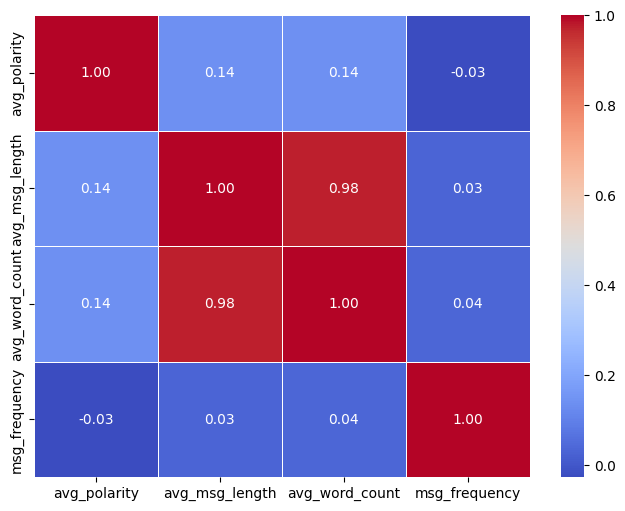

In [27]:
numeric_df = monthly_features.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

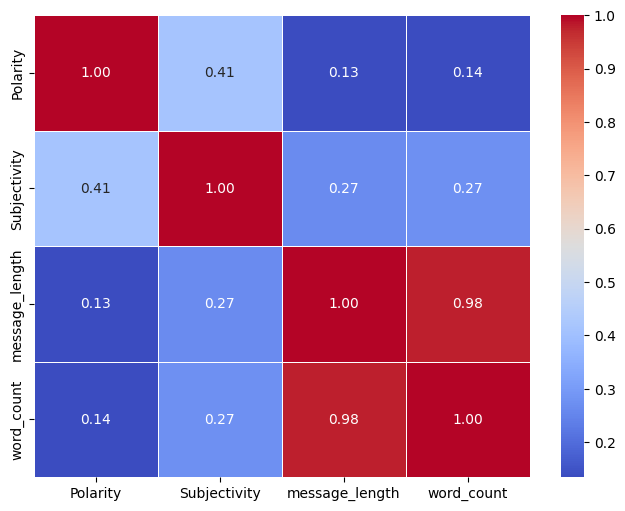

In [28]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

## from these correlation heatmap we can observe that the relation between sentiment polarity and other features to be very weak relation 

In [30]:
from transformers import pipeline
import numpy as np

sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def calcpolarity(msg):
    result = sentiment_pipeline(msg, truncation=True, max_length=512)[0]
    score = result['score']
    polarity = score if result['label'] == 'POSITIVE' else -score
    return polarity

def calcsubjectivity(msg):
    result = sentiment_pipeline(msg, truncation=True, max_length=512)[0]
    return result['score']

def segmentation(polarity_score):
    if polarity_score > 0:
        return 'positive'
    elif polarity_score < 0:
        return 'negative'
    else:
        return 'neutral'

Device set to use cuda:0


In [31]:
df["PolarityB"] = df["clean_body"].apply(calcpolarity) # Cleaning msg in body 
df["SegmentationB"] = df["Polarity"].apply(segmentation) # C
#adding the coloums to our dataframe


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [32]:
df

,Subject,body,date,Employee,clean_body,Polarity,Subjectivity,Segmentation,year_month,message_length,word_count,PolarityB,SegmentationB
0,EnronOptions Update!,"EnronOptions Announcement\n\n\nWe have updated the EnronOptions =01) Your Stock Option Program web site! =\nThe=20\nweb site now contains specific details of the EnronOptions Program includin=\ng=20\nthe December 29, 2000 grant price and additional information on employee=20\neligibility.\n\nAccess EnronOptions =01) Your Stock Option Program web site by clicking on=\n=20\nhttp://hrweb.enron.com or by typing the address into your web browser.\n\nWe hope you find the revised site helpful in addressing your questions abou=\nt=20\nthe EnronOptions Program. If you have any additional questions, please=20\ncontact your H.R. Representative.\n\nStay tuned for more information throughout March and April 2001.",2010-05-10,sally.beck@enron.com,enronoptions announcement we have updated the enronoptions your stock option program web site the web site now contains specific details of the enronoptions program includin g the december grant price and additional information on employee eligibility access enronoptions your stock option program web site by clicking on or by typing the address into your web browser we hope you find the revised site helpful in addressing your questions abou t the enronoptions program if you have any additional questions please contact your hr representative stay tuned for more information throughout march and april,0.250000,0.312500,positive,2010-05,692,101,-0.993285,positive
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to work for the revenue model for mid & \nback office services meeting. How about this coming Monday, Feb 26 from 1:00 \n- 2:30 pm? I have penciled in that time for Sally, Mary Solmonson & James \nScribner. Please let me know if that will work for you.\n\nThanks,\nPatti x39106",2010-07-29,eric.bass@enron.com,marc unfortunately today is not going to work for the revenue model for mid back office services meeting how about this coming monday feb from i have penciled in that time for sally mary solmonson james scribner please let me know if that will work for you thanks patti x,-0.075000,0.300000,negative,2010-07,315,57,-0.984873,negative
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 AM (GMT-06:00) Central Time (US & Canada).\nWhere: @ 10:00am CST (225) 931-8111\n\n*~*~*~*~*~*~*~*~*~*\n\n",2011-07-25,sally.beck@enron.com,when wednesday june gmt central time us canada where cst,0.000000,0.250000,neutral,2011-07,150,21,-0.771551,neutral
3,RE: My new work email,we were thinking papasitos (we can meet somewhere closer to you this time) \nagain at around 8\n\n\n\n\nJason Bass <JBass@stdauto.com> on 02/21/2001 11:22:45 AM\n,2010-03-25,johnny.palmer@enron.com,we were thinking papasitos we can meet somewhere closer to you this time again at around jason bass jbasscom on,-0.150000,0.500000,negative,2010-03,155,24,0.964816,negative
4,Bet,"Since you never gave me the $20 for the last time we bet on CU/Texas, I figured I would give you the chance to go double or nothing on the second round. I think the line is Texas -9. Let me know.",2011-05-21,lydia.delgado@enron.com,since you never gave me the for the last time we bet on cutexas i figured i would give you the chance to go double or nothing on the second round i think the line is texas let me know,-0.050000,0.116667,negative,2011-05,197,42,0.852466,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2186,Re: Resume,Thanks for the resume. She has had some good experience. Do you know much \nabout her performance here at Enron? Can I call and talk with her directly? \nI would certainly keep the conversation confidential at this point. --Sally \n\n\n\n\nVince J Kaminski\n11/21/2000 08:14 AM\n,2011-06-17,johnny.palmer@enron.com,thanks for the resume she has had some good experience do you know much about her performance here at enron can 

In [33]:
# Basic text-based numeric features
df['message_length'] = df['body'].str.len()
df['word_count'] = df['body'].str.split().str.len()

# Group-level monthly features
monthly_featuresB = (
    df.groupby(['Employee', 'date'])
      .agg({
          'PolarityB': 'mean',          # avg sentiment
          'message_length': 'mean',    # avg msg length
          'word_count': 'mean',        # avg word count
          'body': 'count'              # message frequency
      })
      .rename(columns={
          'PolarityB': 'avg_polarity',
          'message_length': 'avg_msg_length',
          'word_count': 'avg_word_count',
          'body': 'msg_frequency'
      })
      .reset_index()
)

monthly_featuresB.head()


,Employee,date,avg_polarity,avg_msg_length,avg_word_count,msg_frequency
0,bobette.riner@ipgdirect.com,2010-01-23,-0.968890,67.000000,11.000000,1
1,bobette.riner@ipgdirect.com,2010-01-25,-0.993667,163.000000,26.000000,1
2,bobette.riner@ipgdirect.com,2010-02-03,-0.882212,890.000000,135.000000,1
3,bobette.riner@ipgdirect.com,2010-02-05,0.772677,172.000000,31.000000,1
4,bobette.riner@ipgdirect.com,2010-02-08,0.451774,377.333333,61.333333,3


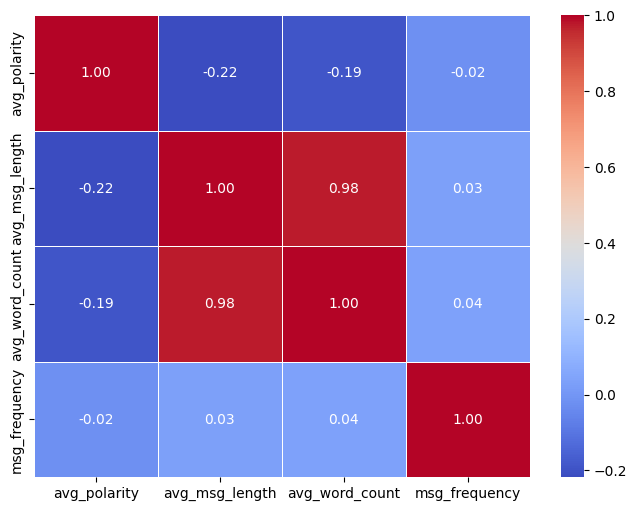

In [34]:
numeric_df = monthly_featuresB.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

### Even changing to Bert based for sentimental analysis we still arent able to get a strong correlation 

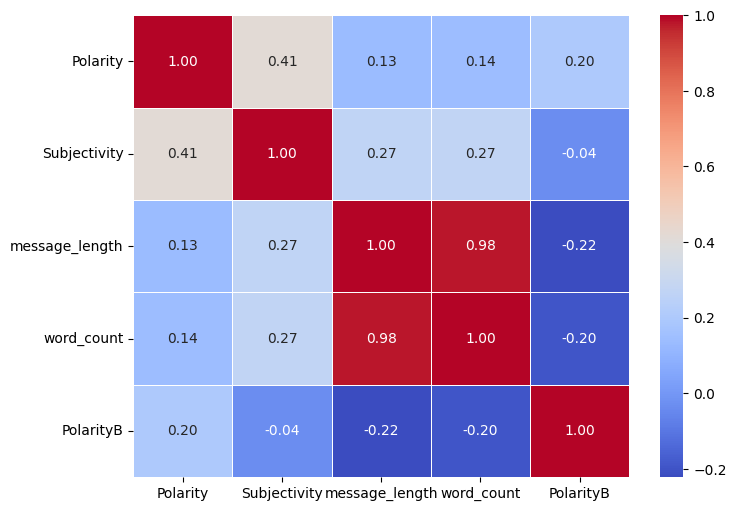

In [35]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()